<a href="https://colab.research.google.com/github/NoaTal1996/Backbone-Graph/blob/main/src/Topic_Clustring_and_NER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instalations and Imports

In [1]:
try:
    # Running inside Google Colab → use !pip
    import google.colab
    in_google_colab = True
    print("Running in Colab → installing packages...")
    !pip install -q bertopic
    !pip install -q tweet-preprocessor
    !pip install -q spacy-entity-linker
    !pip install -q emoji
    !pip install sentence-transformers scikit-learn
    !pip install "transformers>=4.40.0" sentencepiece accelerate torch
except ImportError:
    # Not running in Colab
    in_google_colab = False
    pass

In [2]:
import pandas as pd
import pyarrow  # ensures pandas can read/write parquet
import matplotlib.pyplot as plt

import re
import emoji

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

import spacy

from tqdm.auto import tqdm
from IPython.display import display

# Loading and Exporting
[Labeled Datasets for Research on Information Operations](https://zenodo.org/records/14189193)

## Load Data

In [3]:
dataset_name = "Labeled_Datasets/Ecuador"  # folder path
file_name = f"Ecuador_part_1.gzip.parquet"  # file name

# if run local: put data in "../data/<dataset_name>/<file_name>"
# Recommended: working directory is: "Backbone-Graph/src"

In [4]:
from pathlib import Path

# Google Colab
if in_google_colab:
    from google.colab import drive
    drive.mount('/content/drive')
    dataset_path = Path("/content/drive/Shareddrives/KeyBoostAuthor") / dataset_name / file_name
    print("Running inside Colab. Loading from Google Drive...")

# Cluster\Local
else:
    # Recommended: working directory is: "Backbone-Graph/src"
    dataset_path = Path("../data") / dataset_name / file_name
    print(f"Running on local/cluster.\nLoading data from: {dataset_path}")


# Load the parquet file
df = pd.read_parquet(dataset_path)

# for testing
df = df.sample(n=100, random_state=42).copy()

Running on local/cluster.
Loading data from: ../data/Labeled_Datasets/Ecuador/Ecuador_part_1.gzip.parquet


## Output Path


In [5]:
from datetime import datetime
today = datetime.now().strftime("%Y_%m_%d")


dataset_path = Path(dataset_path)


if in_google_colab:
  output_folder_path = (dataset_path.parents[2] / "Labeled_Dataset_with_Topic_NER" / dataset_path.parent.name / dataset_path.name)
else:
  # working directory is: Backbone-Graph/src
  file_name_no_suffixes = file_name.split(".")[0]
  output_folder_path = Path("../results") / dataset_name / file_name_no_suffixes / today
  # Example: ""../results/Labeled_Datasets/Ecuador/Ecuador_part_4/2025_11_27"



output_folder_path.mkdir(parents=True, exist_ok=True) # Createst the output directory if needed

print(f"output_folder_path = {output_folder_path}")

output_folder_path = ../results/Labeled_Datasets/Ecuador/Ecuador_part_1/2025_12_14


In [6]:
df.head()

,postid,post_text,application_name,post_language,in_reply_to_postid,in_reply_to_accountid,post_time,accountid,account_profile_description,follower_count,following_count,account_creation_date,is_repost,reposted_accountid,reposted_postid,hashtags,urls,account_mentions,is_control
33553,a885e35f47b37dbf8d6523e6d1cb326750ca14ff3e,@fc90d644020a23df2eb4c26373d222fb48c2e8eb6b fc...,b9052708258f305d40d00a13826c6cb32520a2d48c,en,None,None,2011-11-16 21:22:51,305bdcf6fcd806f0711f50ca6fb5f13fe54ccdf7ff,"I retweet nude boob, breast and busty tits lin...",30947,5,2009-06-22,False,None,None,"[tits, twitterafterdark, sexy, nsfw, winning, ...",[https://28996df6cb2615e6d83cc955a21f300da9aa1...,"[fc90d644020a23df2eb4c26373d222fb48c2e8eb6b, 3...",True
9427,97268ff33a5391a7c9e98970ab8fd7a77ad3ffd684,@c81c8ad3384e63e1027a12aa487c58ba9967bb8121 @7...,2727201c363b6fc4afe259ba4094ae0c49cb4df224,None,4193919dab08bcb9f8024e31e56e7c100f8e6aca21,c81c8ad3384e63e1027a12aa487c58ba9967bb8121,2011-04-15 03:31:00,71cc57155d061d447c2c65756c7dfd6873e403a097,🍃🧚‍♀️🧜‍♀️👑,3618,2055,2009-12-22,False,None,None,[],[],"[c81c8ad3384e63e1027a12aa487c58ba9967bb8121, 7...",False
199,b69f3d10bbc8126734f0125bd30acd8e679729d98f,I feel like I'm wasting my time -,62010408238d4a0f958ec97eec3db0a4f69bcd0d11,en,None,None,2010-08-22 23:57:47,bde5efb0a08f2c83b40b97fbe57eb62e1f5d7fd5e4,None,179,161,2009-08-14,True,7dd12ede51c1c9036a60dd2057e5afed31187437c5,e292b4add24048c9baa59bca3d74f1fa1ad36b8cc4,[],[],[7dd12ede51c1c9036a60dd2057e5afed31187437c5],True
12447,f8967f139e2f255f184c5b6b41db467527f42fce90,@9d72355c890e1bb8530156865c0d4172bc3a2926cd Al...,e278f5ccf53957cccf9e97b2ae3fec72d5b892f850,None,None,None,2011-05-10 19:00:00,86f64e2fce5d67c880f1d220f60205d26692ae9e6d,Abogada. Madre de dos príncipes.,135,141,2009-06-19,False,None,None,[],[],[9d72355c890e1bb8530156865c0d4172bc3a2926cd],False
39489,57785b5ad7e2d3d4b6f82b66cba9b0bc76a740e758,"#Messi, feliz porque su país se siente “orgull...",042bc4a3f4973060f4b166ba92732fc75b9f58ffc8,es,None,None,2012-01-09 15:49:03,f72876e465be073b329ab221a21558f99a6535793b,El Diario informativo más comprometido con la ...,2237136,4021,2008-04-08,False,None,None,[Messi],[https://c45b5d07c7547ecc3bec497b91663a6170362...,[],True


# Dataset Statistics

In [7]:
total_posts = len(df)
hashtag_posts = df[df['hashtags'].notna() & (df['hashtags'].str.len() > 0)]
mention_posts = df[df['account_mentions'].notna() & (df['account_mentions'].str.len() > 0)]
url_posts = df[df['urls'].notna() & (df['urls'].str.len() > 0)]

print(f"{'df shape:':<40} {df.shape}")
print(f"{'df posts with hashtags # shape:':<40} {hashtag_posts.shape}  ({len(hashtag_posts)/total_posts*100:.2f}%)")
print(f"{'df posts with account_mentions @ shape:':<40} {mention_posts.shape}  ({len(mention_posts)/total_posts*100:.2f}%)")
print(f"{'df posts with urls shape:':<40} {url_posts.shape}  ({len(url_posts)/total_posts*100:.2f}%)")


print()
print()

print(f"{'**collum name**':<30} **value type**")
for col in df.columns:
    # dtype_str = str(df[col].dtype)  # Convert dtype to string
    # get a sample non-null value if exists
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col:<30} | {type(sample_val).__name__}")


print()
print()
print(df['post_language'].value_counts())

df shape:                                (100, 19)
df posts with hashtags # shape:          (37, 19)  (37.00%)
df posts with account_mentions @ shape:  (51, 19)  (51.00%)
df posts with urls shape:                (25, 19)  (25.00%)


**collum name**                **value type**
postid                         | str
post_text                      | str
application_name               | str
post_language                  | str
in_reply_to_postid             | str
in_reply_to_accountid          | str
post_time                      | Timestamp
accountid                      | str
account_profile_description    | str
follower_count                 | int64
following_count                | int64
account_creation_date          | date
is_repost                      | bool
reposted_accountid             | str
reposted_postid                | str
hashtags                       | ndarray
urls                           | ndarray
account_mentions               | ndarray
is_control                     

# Clean Text

In [8]:
def clean_url(url_match):

    url = url_match.group(0)

    # 1. Remove protocol (http:// or https://)
    url = re.sub(r"https?://", "", url)
    url = re.sub(r"www\.", "", url)

    # 2. Remove query parameters (?x=1)
    url = url.split("?")[0]

    # 3. Split into components by "/"
    parts = url.split("/")

    # Domain (first part)
    domain = parts[0].replace(".", "_")  # twitter.com → twitter_com

    # First section (second part of the URL)
    if len(parts) > 1 and parts[1].strip() != "":
        section = parts[1].replace(".", "_")
        token = f" URL_{domain}_{section} "
    else:
        token = f" URL_{domain} "

    return token


In [9]:
def clean_text(text: str) -> str:

    # lowercase
    text = str(text).lower()

    # URLs → domian + first section
    text = re.sub(r"(https?://\S+|www\.\S+)", clean_url, text)

    # Hashtags → HASHTAG_xxx
    text = re.sub(r"#(\w+)", r" HASHTAG_\1 ", text)

    # Mentions → MENTION_xxx
    text = re.sub(r"@(\w+)", r" MENTION_\1 ", text)

    # emoji → EMOJI_xxx
    text = emoji.demojize(text, delimiters=(" EMOJI_", " "))

    # Collapse spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [10]:
df["clean_post_text"] = df["post_text"].apply(clean_text)

## Remove Enttities Enteties

In [11]:
import re
import pandas as pd

URL_RE = re.compile(r"(https?://\S+|www\.\S+)", flags=re.IGNORECASE)
MENTION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#(\w+)")
WHITESPACE_RE = re.compile(r"\s+")

def clean_enteties(text: str) -> str:
    """
    Lightly clean a social-media post while keeping it natural
    for machine translation.

    Operations:
    - Replace URLs with <URL>
    - Replace @username with <USER>
    - Turn #hashtag into 'hashtag' (drop the #)
    - Collapse repeated whitespace
    """
    if not isinstance(text, str):
        text = str(text)

    # lowercase
    text = str(text).lower()

    # 1. Normalize URLs
    text = URL_RE.sub("<URL>", text)

    # 2. Normalize mentions
    text = MENTION_RE.sub("<USER>", text)

    # 3. Normalize hashtags: "#Ecuador2025" -> "Ecuador2025"
    text = HASHTAG_RE.sub(r"\1", text)

    # 4. Collapse whitespace
    text = WHITESPACE_RE.sub(" ", text).strip()

    return text

In [12]:
df["clean_text_no_enteties"] = df["post_text"].astype(str).apply(clean_enteties)

In [13]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 2000)

df[["post_text", "clean_text_no_enteties"]].sample(n=20)

,post_text,clean_text_no_enteties
42111,"#iLikeWhenYou give me cookies! - ""Cookie boy"" Lol gotta love that kid.","ilikewhenyou give me cookies! - ""cookie boy"" lol gotta love that kid."
47522,Nada. Twitteo a velocidad luz. RT @296c6cb3f555738c62dfc21d3360d61939f15a0f4b Not sure si @074153d9ff70f9008b25c645dd36ec50370809136c está escribiendo todos esos tuits o los tenía en su borrador D:,nada. twitteo a velocidad luz. rt <USER> not sure si <USER> está escribiendo todos esos tuits o los tenía en su borrador d:
27578,@f1045f122349a24fbe68059593c0d7059cf2443ebe jajajaja,<USER> jajajaja
26335,Desayunando y cantando con @2fddfeb32db32e35edcb2bad32c3fd4f62a326585d #Benditatuluz,desayunando y cantando con <USER> benditatuluz
40040,"@cf33c72075fb13ddeb8a8b9e1745891679b585276c Para q eso ocurra, AP de Manabí debe estar en las calles,en los barrios exigiendo la obra,provicnia rica en el agro @2087399d0b911ed0bb43aa9da21d7301f0a077e56c","<USER> para q eso ocurra, ap de manabí debe estar en las calles,en los barrios exigiendo la obra,provicnia rica en el agro <USER>"
4892,Tabla de posiciones LVBP 2010 Miércoles 15 de Diciembre https://a02fe7fc0476d00b8e6ea328acc324ed09b405ae1b,tabla de posiciones lvbp 2010 miércoles 15 de diciembre <URL>
28102,Inaugurando el bar #AKBAR de mi panita sapito @63443d2c4d79d9bb16258df0bea8d5d28c9a4d55e0,inaugurando el bar akbar de mi panita sapito <USER>
36958,Alguien podría enumerar los logros de la Defensoría del Pueblo @ed92ae882a10c6c57aad6af994794bab65e5f47188 ; sin contar la defensa de #Cacho?,alguien podría enumerar los logros de la defensoría del pueblo <USER> ; sin contar la defensa de cacho?
26803,La conciencia es el mejor libro moral que tenemos. Pascal,la conciencia es el mejor libro moral que tenemos. pascal
34657,"A menos de que seas Wikipedia, deja de comportarte como si lo supieras todo.","a menos de que seas wikipedia, deja de comportarte como si lo supieras todo."


# Translation to English

In [14]:
# map post_language codes to NLLB-200 language codes
# https://dl-translate.readthedocs.io/en/latest/available_languages/

def map_to_nllb_code(lang_code: str) -> str:
    """
    Map your dataset's post_language codes to NLLB-200 language codes.
    If not in mup return the same language code.
    Args:
        lang_code (str): Post language code.
    Returns:
        str: NLLB-200 language code.
    """
    nlln_mapping = {
    # Europe
    "en": "eng_Latn",   # English
    "es": "spa_Latn",   # Spanish
    "pt": "por_Latn",   # Portuguese
    "fr": "fra_Latn",   # French
    "de": "deu_Latn",   # German
    "it": "ita_Latn",   # Italian
    "nl": "nld_Latn",   # Dutch
    "ru": "rus_Cyrl",   # Russian
    "pl": "pol_Latn",   # Polish
    "sv": "swe_Latn",   # Swedish
    "ca": "cat_Latn",    # Catalan
    "cy": "cym_Latn",    # Welsh
    "et": "est_Latn",    # Estonian

    # Middle East
    "ar": "arb_Arab",   # Arabic (MSA)
    "he": "heb_Hebr",   # Hebrew
    "tr": "tur_Latn",   # Turkish
    "fa": "pes_Arab",   # Persian/Farsi

    # South Asia
    "hi": "hin_Deva",   # Hindi
    "ur": "urd_Arab",   # Urdu
    "bn": "ben_Beng",   # Bengali

    # East Asia
    "zh": "zho_Hans",   # Chinese Simplified
    "ja": "jpn_Jpan",   # Japanese
    "ko": "kor_Hang",   # Korean

    # Southeast Asia
    "vi": "vie_Latn",   # Vietnamese
    "id": "ind_Latn",   # Indonesian (modern code)
    "in": "ind_Latn",   # Indonesian (legacy ISO code)
    "tl": "tgl_Latn",   # Tagalog (Philippines)

    # Africa
    "sw": "swh_Latn",   # Swahili

    # Americas
    "qu": "quy_Latn",   # Quechua (Ayacucho)
}


    if lang_code in nlln_mapping:
        return nlln_mapping[lang_code]
    else:
        return lang_code

In [15]:
df["post_language"] = df["post_language"].apply(map_to_nllb_code)

In [16]:
# load models

import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline

MODEL_NAME = "facebook/nllb-200-distilled-600M"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)
translation_pipeline = pipeline("translation", model=model, tokenizer=tokenizer, device=device, max_length=1000, batch_size=16)

Using device: cuda


Device set to use cuda


In [17]:
from tqdm.auto import tqdm


def transformers_translator(
    df: pd.DataFrame,
    translation_pipe,
    text_col: str = "clean_text_no_enteties",
    lang_col: str = "post_language",
    out_col: str = "translated_post",
    target_lang: str = "eng_Latn",
    pivot_lang: str = "spa_Latn",
    backtranslate_same_lang: bool = True,
) -> pd.DataFrame:
    """
    Translate df[text_col] → target_lang using NLLB pipeline.

    If src_lang == target_lang and backtranslate_same_lang=True,
    perform back-translation: target_lang → pivot_lang → target_lang.

    Args:
        df (pd.DataFrame):
            Input DataFrame containing text and language labels.
        translation_pipe (transformers.pipeline):
            Pre-loaded translation pipeline (e.g., NLLB-200).
        text_col (str):
            Column containing original text.
        lang_col (str):
            Column containing language codes matching the pipeline
            (e.g., "spa_Latn", "eng_Latn").
        out_col (str):
            Column name for the translated output.
        target_lang (str):
            Target language code (default: "eng_Latn").
        pivot_lang (str):
            Pivot language code for back-translation (default: "spa_Latn").
        backtranslate_same_lang (bool):
            If True, back-translate rows where src_lang == target_lang.

    Returns:
        pd.DataFrame:
            A DataFrame with the same index as df and one column (out_col).
    """

    result_df = pd.DataFrame(index=df.index)
    result_df[out_col] = None

    # Iterate per language with progress bar
    for src_lang, group in tqdm(df.groupby(lang_col), desc="Translating by language"):

        # Build a list[str]
        texts = group[text_col].astype(str).tolist()

        # Keep the original indexes so we can assign back later
        indexes = group.index.to_list()

        translated = []  # empty means "no translation done"

        # Case 1: normal translation src_lang -> target_lang
        if src_lang != target_lang:
            print(f"{len(texts)} posts: {src_lang} → {target_lang}")
            outputs = translation_pipe(
                texts,
                src_lang=src_lang,
                tgt_lang=target_lang,
            )
            translated = [o["translation_text"] for o in outputs]

        # Case 2: back-translation target_lang -> pivot_lang -> target_lang
        if (src_lang == target_lang) and backtranslate_same_lang:
            print(f"{len(texts)} posts: {target_lang} → {pivot_lang} → {target_lang}")
            pivot_outputs = translation_pipe(
                texts,
                src_lang=target_lang,
                tgt_lang=pivot_lang,
            )
            pivot_texts = [o["translation_text"] for o in pivot_outputs]

            back_outputs = translation_pipe(
                pivot_texts,
                src_lang=pivot_lang,
                tgt_lang=target_lang,
            )
            translated = [o["translation_text"] for o in back_outputs]

        if translated:
            result_df.loc[indexes, out_col] = translated

    return result_df

In [18]:
print(f"df shape: {df.shape}")
translated_df = transformers_translator(df, translation_pipeline)
df = df.drop(columns=["translated_post"], errors="ignore") # Drop the old column if exist
df = df.join(translated_df)

df shape: (100, 21)


Translating by language:   0%|          | 0/5 [00:00<?, ?it/s]

19 posts: eng_Latn → spa_Latn → eng_Latn
4 posts: por_Latn → eng_Latn
43 posts: spa_Latn → eng_Latn
1 posts: tgl_Latn → eng_Latn
3 posts: und → eng_Latn


In [19]:
pd.set_option("display.width", 3000)
pd.set_option("display.max_colwidth", 1500)

df.sample(10)[["clean_text_no_enteties", "translated_post"]]

,clean_text_no_enteties,translated_post
2530,<USER> jajajajajajajajaj ahh ya fueron a casa de asdrubal? jajajajaj bieen hecho u.u eso pasa xque yo no fui xd,None
30188,pacientes epilépticos no encuentran medicamentos para su tratamiento <URL> así se garantiza el derecho a la salud en vzla!!!,epileptic patients can't find medication for their treatment <URL> so the right to health is guaranteed in vzla!!!
27578,<USER> jajajaja,None
47522,nada. twitteo a velocidad luz. rt <USER> not sure si <USER> está escribiendo todos esos tuits o los tenía en su borrador d:,Nothing. Tweeting at light speed. rt <USER> not sure if <USER> is writing all those tweets or had them in his draft d:
30638,"""stay positive in life and tough situations, and you'll succeed farther in life than ever before."" bau5","""Keep positive in life and in difficult situations, and you will be more successful in life than ever""."
40040,"<USER> para q eso ocurra, ap de manabí debe estar en las calles,en los barrios exigiendo la obra,provicnia rica en el agro <USER>","For that to happen, parents must be on the streets, in the neighbourhoods demanding the work, rich in agriculture."
38695,<USER> así es,None
30001,con mi bby <USER> &lt;3,with my bby <USER> &lt;3
49146,"morre,ygor.morra gabriel","He dies, Yegor. He dies Gabriel."
4892,tabla de posiciones lvbp 2010 miércoles 15 de diciembre <URL>,Table of positions lvbp 2010 Wednesday 15 December <URL>


# Remove Engllish Stopwords

In [20]:
from nltk.corpus import stopwords
import nltk

In [21]:
nltk.download('stopwords')

EXTRA_STOPWORDS = [
    'he', 'she', 'they', 'you', 'i', 'we', 'im', 'hes', 'shes', 'its', 'rt', 'amp', 're',
    'theyre', 'dont', 'doesnt', 'would', 'could', 'like', 'know', 'say', 'said', 'one',
    'look', 'looks', 'think', 'oh', 'yeah', 'guy', 'gonna', 'thing', 'someone', 'people',
    'get', 'got', 'thats', 'just', 'really', 'even', 'still', 'want', 'need', 'needs',
    'me', 'to', 'you', 'the', 'that', 'be', 'my', 'get', 'in', 'and',
     'rt', 'the', 'https', 'to', 'my', 'it', 'on', 'you', 'of', 'for', 'https', 'http', 'RT'
]
all_stopwords_english = set(stopwords.words('english') + EXTRA_STOPWORDS)

def remove_stopwords(text):
    return " ".join([w for w in text.lower().split() if w not in all_stopwords_english])


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/amitner/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [22]:
df["clean_post_text"] = df["clean_post_text"].apply(remove_stopwords)

In [23]:
df[["post_text", "clean_post_text"]].head(20)

,post_text,clean_post_text
33553,@fc90d644020a23df2eb4c26373d222fb48c2e8eb6b fc90d644020a23df2eb4c26373d222fb48c2e8eb6b: https://28996df6cb2615e6d83cc955a21f300da9aa185a73 @305bdcf6fcd806f0711f50ca6fb5f13fe54ccdf7ff #tits #twitterafterdark #sexy #nsfw #winning #amateur,mention_fc90d644020a23df2eb4c26373d222fb48c2e8eb6b fc90d644020a23df2eb4c26373d222fb48c2e8eb6b: url_28996df6cb2615e6d83cc955a21f300da9aa185a73 mention_305bdcf6fcd806f0711f50ca6fb5f13fe54ccdf7ff hashtag_tits hashtag_twitterafterdark hashtag_sexy hashtag_nsfw hashtag_winning hashtag_amateur
9427,@c81c8ad3384e63e1027a12aa487c58ba9967bb8121 @72c233209dc9fa95258de4150952791cc619e258cc Q ASCO!!!,mention_c81c8ad3384e63e1027a12aa487c58ba9967bb8121 mention_72c233209dc9fa95258de4150952791cc619e258cc q asco!!!
199,I feel like I'm wasting my time -,feel wasting time -
12447,@9d72355c890e1bb8530156865c0d4172bc3a2926cd Alguien sabe q pasa en la ARC a la altura del antiguo peaje de Hoyo de la Puerta? Ahí mucha cola...,mention_9d72355c890e1bb8530156865c0d4172bc3a2926cd alguien sabe q pasa en la arc la altura del antiguo peaje de hoyo de la puerta? ahí mucha cola...
39489,"#Messi, feliz porque su país se siente “orgulloso” de él https://c45b5d07c7547ecc3bec497b91663a6170362bc8ff","hashtag_messi , feliz porque su país se siente “orgulloso” de él url_c45b5d07c7547ecc3bec497b91663a6170362bc8ff"
42724,@db015c48d7cb5bd6f438327e963b2022e2b9f4b986 hahahaha i am for sumwer ano no yet.lolz,mention_db015c48d7cb5bd6f438327e963b2022e2b9f4b986 hahahaha sumwer ano yet.lolz
10822,@9e58fca9edb89eec88dfc3d3fd34feeafd42af5856 feliz día a los diseñadores gráficos,mention_9e58fca9edb89eec88dfc3d3fd34feeafd42af5856 feliz día los diseñadores gráficos
49498,Para #barcelona #bsc ganarle a #LIGA #ldu no es un sueño... Es mision imposible! Catedra en la cancha y en las gradas Grande LIGA y MB &lt;3,para hashtag_barcelona hashtag_bsc ganarle hashtag_liga hashtag_ldu es un sueño... es mision imposible! catedra en la cancha en las gradas grande liga mb &lt;3
4144,#animalnocturno,hashtag_animalnocturno
36958,Alguien podría enumerar los logros de la Defensoría del Pueblo @ed92ae882a10c6c57aad6af994794bab65e5f47188 ; sin contar la defensa de #Cacho?,alguien podría enumerar los logros de la defensoría del pueblo mention_ed92ae882a10c6c57aad6af994794bab65e5f47188 ; sin contar la defensa de hashtag_cacho ?


# English Topic Clustering

## Utils


### Posts Topic Stats

In [24]:
def make_topic_stats(df, topic_col_name):
    """
    Calculate per-topic post counts.

    Args:
        df (pd.DataFrame): Data with topics and 'is_control'.
        topic_col_name (str): Column name of topic labels.

    Returns:
        topic_stats (pd.DataFrame): Colums: [topic, total_count, io_Count, legitimate_posts, io_percent].
    """
    topic_stats = (
        df.groupby(topic_col_name)
          .agg(
              total_count=(topic_col_name, "count"),
              io_count=("is_control", lambda x: (~x).sum())
          )
          .reset_index()
    )
    topic_stats["legitimate_posts"] = topic_stats["total_count"] - topic_stats["io_count"]
    topic_stats["io_percent"] = topic_stats["io_count"] / topic_stats["total_count"] * 100
    return topic_stats

In [25]:
from matplotlib.lines import Line2D

def plot_topic_stats(topic_stats, topic_col_name, model_name, output_folder_path = ""):
    """
    Plot stacked IO vs legitimate post counts per topic.
    Saves the fig to output_path if provided.

    Args:
        topic_stats (pd.DataFrame): Output of make_topic_stats().
        topic_col_name (str): Topic column to plot.
        output_folder_path (str): Path to *folder* save the plot.

    Returns:
        None
    """
    topics = topic_stats[topic_col_name]
    io_count = topic_stats["io_count"]
    legitimate_count = topic_stats["legitimate_posts"]
    io_percent = topic_stats["io_percent"]

    plt.figure(figsize=(12, 6))

    # 🔴 Bottom: IO posts
    bar_io = plt.bar(topics, io_count, label="IO posts", color="red")

    # 🔵 Top: Non-IO posts stacked above IO
    bar_legit = plt.bar(topics, legitimate_count, bottom=io_count, label="Non-IO posts")

    # Add IO percentage text
    ax = plt.gca()
    for x, io, legit, pct in zip(topics, io_count, legitimate_count, io_percent):
        total_height = io + legit
        ax.text(
            x,
            total_height + 0.5,              # slightly above the bar
            f"{pct:.1f}%",                 # format like 23.5%
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="regular"
        )

    plt.title(f"Post Count per Topic ({model_name})")
    plt.xlabel("Topic ID")
    plt.ylabel("Number of Posts")
    plt.xticks(topics)
    plt.grid(axis="y")
    
    percent_legend = Line2D([], [], color="none")
    total_posts_legend = Line2D([], [], color="none")
    plt.legend(
        handles=[bar_io, bar_legit, percent_legend, total_posts_legend],
        labels=[
            "IO posts",
            "Non-IO posts",
            "% IO Posts Ratio",
            f"Total posts: {topic_stats['total_count'].sum()}",
        ],
        loc="best",
    )

    
    plt.tight_layout()


    if output_folder_path:
        plot_file_path = output_folder_path / (f"{model_name}_topic_clustering.png")
        plt.savefig(plot_file_path, dpi=300)
        print(f"plot is saved to {plot_file_path}")

    plt.show()

    plt.close()

### Accoutns Topic Stats

In [26]:
def make_topic_account_stats(
    df: pd.DataFrame,
    topic_col: str,
    author_col: str = "accountid",
    is_io_control: str = "is_control",
    threshold: float = 0.5,
) -> pd.DataFrame:
    """Compute per-topic unique account counts (IO vs control) using an author-level threshold.

    Args:
        df: Post-level DataFrame.
        topic_col: Topic column name.
        author_col: Author identifier column.
        is_io_control: Column where 1 = control, 0 = IO.
        threshold: IO-rate threshold to label an author as IO (1 = IO).

    Returns:
        pd.DataFrame with per-topic counts of unique IO/control accounts and IO percentage.
    """
    # Author-level IO label (1 = IO)
    author_io_tag = ((1 - df.groupby(author_col)[is_io_control].mean()) >= threshold).astype(int)

    # Topic's authors (unique pairs)
    topic_author_df = df[[topic_col, author_col]].drop_duplicates()
    topic_author_df["author_io_tag"] = topic_author_df[author_col].map(author_io_tag)

    topic_account_stats = (
        topic_author_df
        .groupby(topic_col)["author_io_tag"]
        .value_counts()
        .unstack(fill_value=0)
        .rename(columns={0: "control_accounts", 1: "io_accounts"})
        .reset_index()
    )

    topic_account_stats["total_accounts"] = topic_account_stats["control_accounts"] + topic_account_stats["io_accounts"]
    topic_account_stats["io_percent"] = topic_account_stats["io_accounts"] / topic_account_stats["total_accounts"] * 100

    return topic_account_stats

In [27]:
def plot_topic_account_stats(
    topic_account_stats: pd.DataFrame,
    topic_col_name: str,
    model_name: str,
    output_folder_path: Path | str | None = None,
):
    """Plot IO vs control account counts per topic.

    Args:
        topic_account_stats: Output of make_topic_account_stats().
        topic_col_name: Topic column name.
        model_name: Model name for title / filename.
        output_folder_path: Optional folder to save the plot.

    Returns:
        None
    """
    topics = topic_account_stats[topic_col_name]
    io_count = topic_account_stats["io_accounts"]
    control_count = topic_account_stats["control_accounts"]
    io_percent = topic_account_stats["io_percent"]

    plt.figure(figsize=(12, 6))

    # 🔴 Bottom: IO accounts
    bar_io = plt.bar(topics, io_count, label="IO accounts", color="red")

    # 🔵 Top: Control accounts
    bar_control = plt.bar(
        topics,
        control_count,
        bottom=io_count,
        label="Control accounts",
    )

    # Add IO percentage text
    ax = plt.gca()
    for x, io, ctrl, pct in zip(topics, io_count, control_count, io_percent):
        total = io + ctrl
        ax.text(
            x,
            total + 0.3,
            f"{pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="regular",
        )

    plt.title(f"Unique Accounts per Topic ({model_name})")
    plt.xlabel("Topic ID")
    plt.ylabel("Number of Unique Accounts")
    plt.xticks(topics)
    plt.grid(axis="y")

    # Legend with extra info lines
    percent_legend = Line2D([], [], color="none")
    total_accounts_legend = Line2D([], [], color="none")

    plt.legend(
        handles=[bar_io, bar_control, percent_legend, total_accounts_legend],
        labels=[
            "IO accounts",
            "Control accounts",
            "% IO Accounts Ratio",
            f"Total accounts: {topic_account_stats["total_accounts"].sum()}",
        ],
        loc="best",
    )

    if output_folder_path:
        output_folder_path = Path(output_folder_path)
        plot_file_path = output_folder_path / f"{model_name}_topic_accounts.png"
        plt.savefig(plot_file_path, dpi=300)
        print(f"Plot saved to {plot_file_path}")

    plt.show()
    plt.close()

### Cleaning and Embeddings

In [28]:
clean_posts_text_lst = df["clean_post_text"].to_list()

In [29]:
from sklearn.preprocessing import normalize

# Load model
model = SentenceTransformer("digio/Twitter4SSE")

# Embeddings
embeddings = model.encode(clean_posts_text_lst, show_progress_bar=True)
embeddings = normalize(embeddings)

No sentence-transformers model found with name digio/Twitter4SSE. Creating a new one with mean pooling.


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

## BERTopic

In [30]:
def english_BERTopic_modeling(posts_text_lst, embeddings, output_folder_path= "", min_topic_size=50):
    """
    Run BERTopic using precomputed embeddings.

    Args:
        posts_text_lst (list[str]): English text posts.
        embeddings (np.ndarray): Precomputed embeddings aligned with the posts.
        min_topic_size (int): Minimum cluster size.

    Returns:
        topics, probs, topic_model
    """
    topic_model = BERTopic(
        language="english",
        min_topic_size=min_topic_size,
        verbose=True # show logs
    )

    topics, probs = topic_model.fit_transform(posts_text_lst, embeddings)

    # save model to folder
    if output_folder_path:
        topic_model.save(output_folder_path / "BERTopic_model")
        print(f"BERTopic model is saved to {output_folder_path}")

    return topics, probs, topic_model


In [31]:
BERTopic_topic, BERT_probs, BERTopic_model = english_BERTopic_modeling(clean_posts_text_lst, embeddings, output_folder_path)

df["BERTopic_topic"] = BERTopic_topic
df["BERTopic_prob"] = BERT_probs


BERTopic_model.get_topic_info()

2025-12-14 13:07:54,516 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-14 13:08:01,792 - BERTopic - Dimensionality - Completed ✓
2025-12-14 13:08:01,792 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-14 13:08:01,817 - BERTopic - Cluster - Completed ✓
2025-12-14 13:08:01,819 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-14 13:08:01,837 - BERTopic - Representation - Completed ✓
2025-12-14 13:08:01,841 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


BERTopic model is saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_1/2025_12_14


,Topic,Count,Name,Representation,Representative_Docs
0,-1,100,-1_de_la_en_el,"[de, la, en, el, que, para, con, sorry, es, un]","[puedo con la imagen de los niños dormidos la madre contando el cuento :'( hashtag_titanic, mention_9d72355c890e1bb8530156865c0d4172bc3a2926cd alguien sabe q pasa en la arc la altura del antiguo peaje de hoyo de la puerta? ahí mucha cola..., mention_cf33c72075fb13ddeb8a8b9e1745891679b585276c para q eso ocurra, ap de manabí debe estar en las calles,en los barrios exigiendo la obra,provicnia rica en el agro mention_2087399d0b911ed0bb43aa9da21d7301f0a077e56c]"


In [32]:
def make_topic_posts_table(
    df,
    topic_col="BERTopic_topic",
    prob_col="BERTopic_prob",
    text_col="post_text",
    top_k=5,
    max_chars=300,
):
    top_posts = (
        df[[topic_col, prob_col, text_col]]
        .dropna(subset=[topic_col, prob_col, text_col])
        .sort_values([topic_col, prob_col], ascending=[True, False])
        .groupby(topic_col, as_index=False)
        .head(top_k)
        .copy()
    )

    # rank within each topic (1..top_k)
    top_posts["rank"] = top_posts.groupby(topic_col).cumcount() + 1

    # enforce uniqueness (topic, rank) -> one row
    top_posts = top_posts.drop_duplicates(subset=[topic_col, "rank"], keep="first")

    topic_posts_table = (
        top_posts.pivot(index=topic_col, columns="rank", values=text_col)
        .rename(columns=lambda i: f"post_{i}")
        .reset_index()
    )

    return topic_posts_table

In [33]:
topic_posts_table = make_topic_posts_table(df, top_k=5)
display(topic_posts_table)

rank,BERTopic_topic,post_1,post_2,post_3,post_4,post_5
0,-1,@fc90d644020a23df2eb4c26373d222fb48c2e8eb6b fc90d644020a23df2eb4c26373d222fb48c2e8eb6b: https://28996df6cb2615e6d83cc955a21f300da9aa185a73 @305bdcf6fcd806f0711f50ca6fb5f13fe54ccdf7ff #tits #twitterafterdark #sexy #nsfw #winning #amateur,@c81c8ad3384e63e1027a12aa487c58ba9967bb8121 @72c233209dc9fa95258de4150952791cc619e258cc Q ASCO!!!,I feel like I'm wasting my time -,@9d72355c890e1bb8530156865c0d4172bc3a2926cd Alguien sabe q pasa en la ARC a la altura del antiguo peaje de Hoyo de la Puerta? Ahí mucha cola...,"#Messi, feliz porque su país se siente “orgulloso” de él https://c45b5d07c7547ecc3bec497b91663a6170362bc8ff"


plot is saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_1/2025_12_14/BERTopic_topic_clustering.png


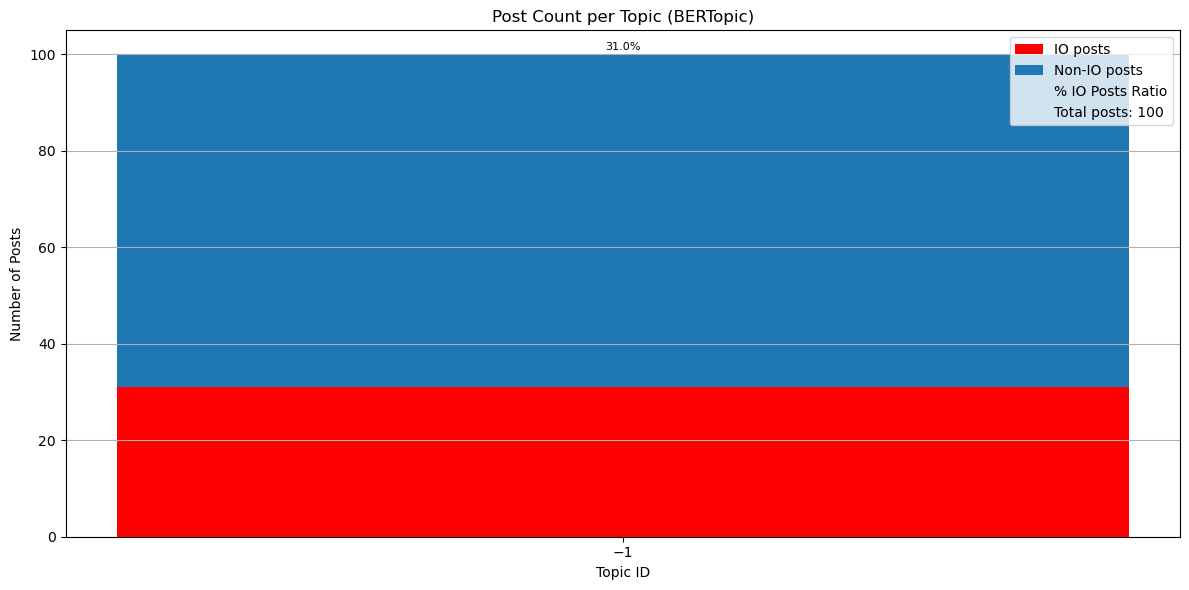

In [34]:
topic_col_name = "BERTopic_topic"
BERT_topic_stats = make_topic_stats(df, topic_col_name)
plot_topic_stats(BERT_topic_stats, topic_col_name, "BERTopic", output_folder_path)

author_io_tag,BERTopic_topic,control_accounts,io_accounts,total_accounts,io_percent
0,-1,64,4,68,5.882353


Plot saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_1/2025_12_14/BERTopic_topic_accounts.png


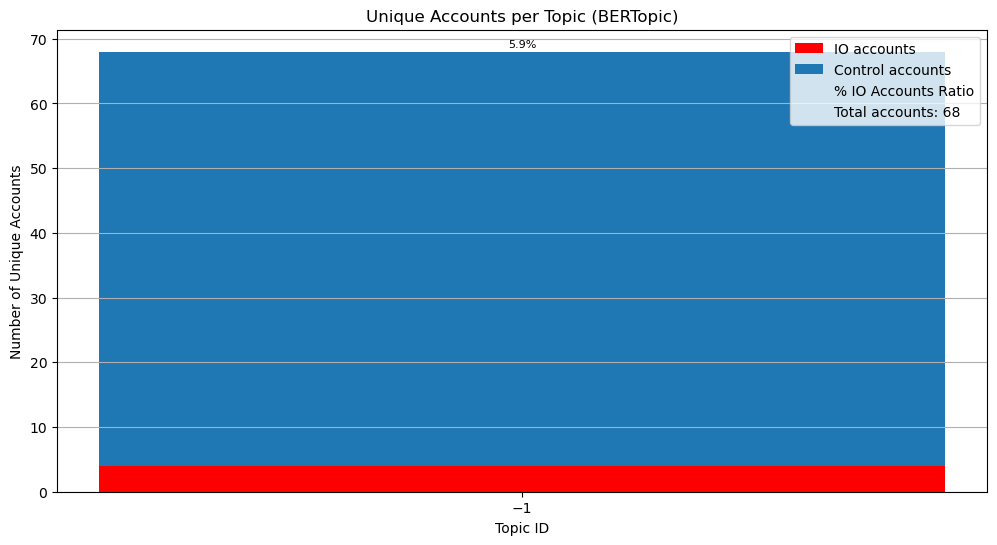

In [35]:
topic_col_name = "BERTopic_topic"

topic_account_stats = make_topic_account_stats(df, topic_col_name)
display(topic_account_stats)
plot_topic_account_stats(topic_account_stats, topic_col_name, "BERTopic", output_folder_path)

In [36]:
try:
    fig = BERTopic_model.visualize_topics(custom_labels=True)
    display(fig)   # show it
except Exception as e:
    print("Not enough topics for visualization")
    print("Error:", e)

Not enough topics for visualization
Error: arrays used as indices must be of integer (or boolean) type


## K-Means

In [37]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def auto_kmeans_topics(embeddings, k_min=4, k_max=40, step = 2):
    best_k = None
    best_score = -1
    best_labels = None

    for k in range(k_min, k_max + 1, step):
        print(f"Trying k={k}")
        km = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = km.fit_predict(embeddings)
        score = silhouette_score(embeddings, labels)

        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

    return best_labels, best_k

In [38]:
# Add to df
labels, best_k = auto_kmeans_topics(embeddings)
df["K_Means_topic"] = labels
print(f"Best k: {best_k}")
df.head()

Trying k=4
Trying k=6
Trying k=8
Trying k=10
Trying k=12
Trying k=14
Trying k=16
Trying k=18
Trying k=20
Trying k=22
Trying k=24
Trying k=26
Trying k=28
Trying k=30
Trying k=32
Trying k=34
Trying k=36
Trying k=38
Trying k=40
Best k: 4


,postid,post_text,application_name,post_language,in_reply_to_postid,in_reply_to_accountid,post_time,accountid,account_profile_description,follower_count,...,hashtags,urls,account_mentions,is_control,clean_post_text,clean_text_no_enteties,translated_post,BERTopic_topic,BERTopic_prob,K_Means_topic
33553,a885e35f47b37dbf8d6523e6d1cb326750ca14ff3e,@fc90d644020a23df2eb4c26373d222fb48c2e8eb6b fc90d644020a23df2eb4c26373d222fb48c2e8eb6b: https://28996df6cb2615e6d83cc955a21f300da9aa185a73 @305bdcf6fcd806f0711f50ca6fb5f13fe54ccdf7ff #tits #twitterafterdark #sexy #nsfw #winning #amateur,b9052708258f305d40d00a13826c6cb32520a2d48c,eng_Latn,None,None,2011-11-16 21:22:51,305bdcf6fcd806f0711f50ca6fb5f13fe54ccdf7ff,"I retweet nude boob, breast and busty tits links. https://75338c1b201c7d83996054cfa846b0ac2190b00f6f From fc194b71dfcd65cdd736cd1b015183ed2e09a07ddf",30947,...,"[tits, twitterafterdark, sexy, nsfw, winning, amateur]",[https://28996df6cb2615e6d83cc955a21f300da9aa185a73],"[fc90d644020a23df2eb4c26373d222fb48c2e8eb6b, 305bdcf6fcd806f0711f50ca6fb5f13fe54ccdf7ff]",True,mention_fc90d644020a23df2eb4c26373d222fb48c2e8eb6b fc90d644020a23df2eb4c26373d222fb48c2e8eb6b: url_28996df6cb2615e6d83cc955a21f300da9aa185a73 mention_305bdcf6fcd806f0711f50ca6fb5f13fe54ccdf7ff hashtag_tits hashtag_twitterafterdark hashtag_sexy hashtag_nsfw hashtag_winning hashtag_amateur,<USER> fc90d644020a23df2eb4c26373d222fb48c2e8eb6b: <URL> <USER> tits twitterafterdark sexy nsfw winning amateur,This Regulation shall enter into force on the twentieth day following that of its publication in the Official Journal of the European Union.,-1,0.0,0
9427,97268ff33a5391a7c9e98970ab8fd7a77ad3ffd684,@c81c8ad3384e63e1027a12aa487c58ba9967bb8121 @72c233209dc9fa95258de4150952791cc619e258cc Q ASCO!!!,2727201c363b6fc4afe259ba4094ae0c49cb4df224,None,4193919dab08bcb9f8024e31e56e7c100f8e6aca21,c81c8ad3384e63e1027a12aa487c58ba9967bb8121,2011-04-15 03:31:00,71cc57155d061d447c2c65756c7dfd6873e403a097,🍃🧚‍♀️🧜‍♀️👑,3618,...,[],[],"[c81c8ad3384e63e1027a12aa487c58ba9967bb8121, 72c233209dc9fa95258de4150952791cc619e258cc]",False,mention_c81c8ad3384e63e1027a12aa487c58ba9967bb8121 mention_72c233209dc9fa95258de4150952791cc619e258cc q asco!!!,<USER> <USER> q asco!!!,None,-1,0.0,0
199,b69f3d10bbc8126734f0125bd30acd8e679729d98f,I feel like I'm wasting my time -,62010408238d4a0f958ec97eec3db0a4f69bcd0d11,eng_Latn,None,None,2010-08-22 23:57:47,bde5efb0a08f2c83b40b97fbe57eb62e1f5d7fd5e4,None,179,...,[],[],[7dd12ede51c1c9036a60dd2057e5afed31187437c5],True,feel wasting time -,i feel like i'm wasting my time -,I feel like I'm wasting my time.,-1,0.0,3
12447,f8967f139e2f255f184c5b6b41db467527f42fce90,@9d72355c890e1bb8530156865c0d4172bc3a2926cd Alguien sabe q pasa en la ARC a la altura del antiguo peaje de Hoyo de la Puerta? Ahí mucha cola...,e278f5ccf53957cccf9e97b2ae3fec72d5b892f850,None,None,None,2011-05-10 19:00:00,86f64e2fce5d67c880f1d220f60205d26692ae9e6d,Abogada. Madre de dos príncipes.,135,...,[],[],[9d72355c890e1bb8530156865c0d4172bc3a2926cd],False,mention_9d72355c890e1bb8530156865c0d4172bc3a2926cd alguien sabe q pasa en la arc la altura del antiguo peaje de hoyo de la puerta? ahí mucha cola...,<USER> alguien sabe q pasa en la arc a la altura del antiguo peaje de hoyo de la puerta? ahí mucha cola...,None,-1,0.0,0
39489,57785b5ad7e2d3d4b6f82b66cba9b0bc76a740e758,"#Messi, feliz porque su país se siente “orgulloso” de él https://c45b5d07c7547ecc3bec497b91663a6170362bc8ff",042bc4a3f4973060f4b166ba92732fc75b9f58ffc8,spa_Latn,None,None,2012-01-09 15:49:03,f72876e465be073b329ab221a21558f99a6535793b,"El Diario informativo más comprometido con la gente de Ecuador. En Facebook, Instagram y TikTok nos encuentras como f6f1a125d387fda775d529ffec68c7b1926448ff99",2237136,...,[Messi],[https://c45b5d07c7547ecc3bec497b91663a6170362bc8ff],[],True,"hashtag_messi , feliz porque su país se siente “orgulloso” de él url_c45b5d07c7547ecc3bec497b91663a6170362bc8ff","messi, feliz porque su país se siente “orgulloso” de él <URL>","

plot is saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_1/2025_12_14/K-Means_topic_clustering.png


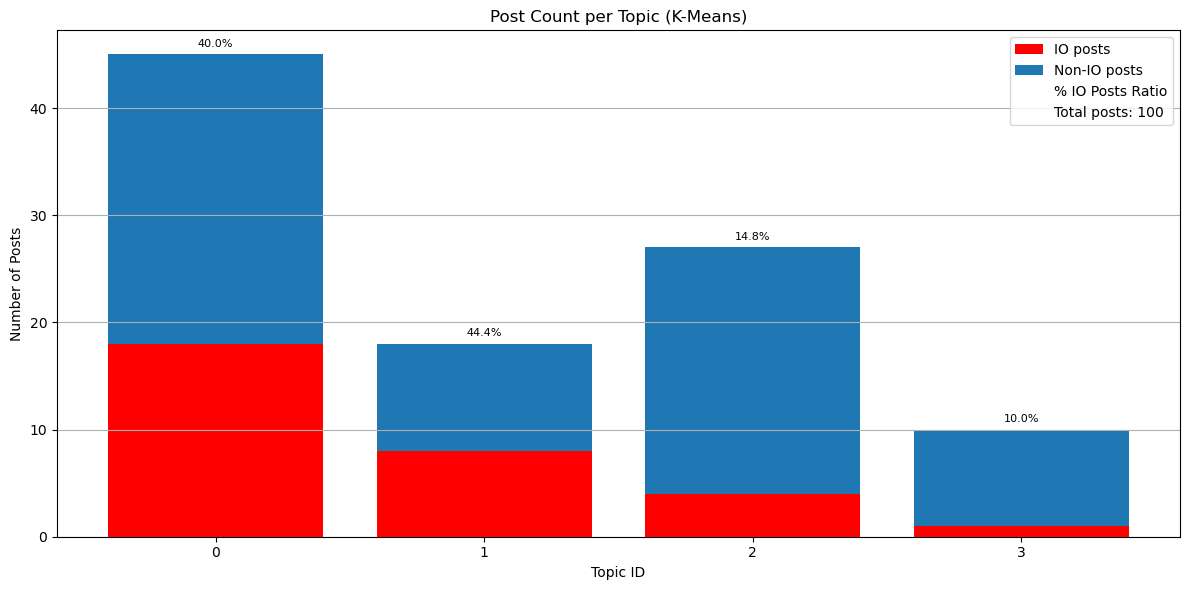

In [39]:
topic_col_name = "K_Means_topic"
topic_stats = make_topic_stats(df, topic_col_name)
plot_topic_stats(topic_stats, topic_col_name, "K-Means", output_folder_path)

author_io_tag,K_Means_topic,control_accounts,io_accounts,total_accounts,io_percent
0,0,26,4,30,13.333333
1,1,10,3,13,23.076923
2,2,22,1,23,4.347826
3,3,9,1,10,10.000000


Plot saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_1/2025_12_14/K_Means_topic_accounts.png


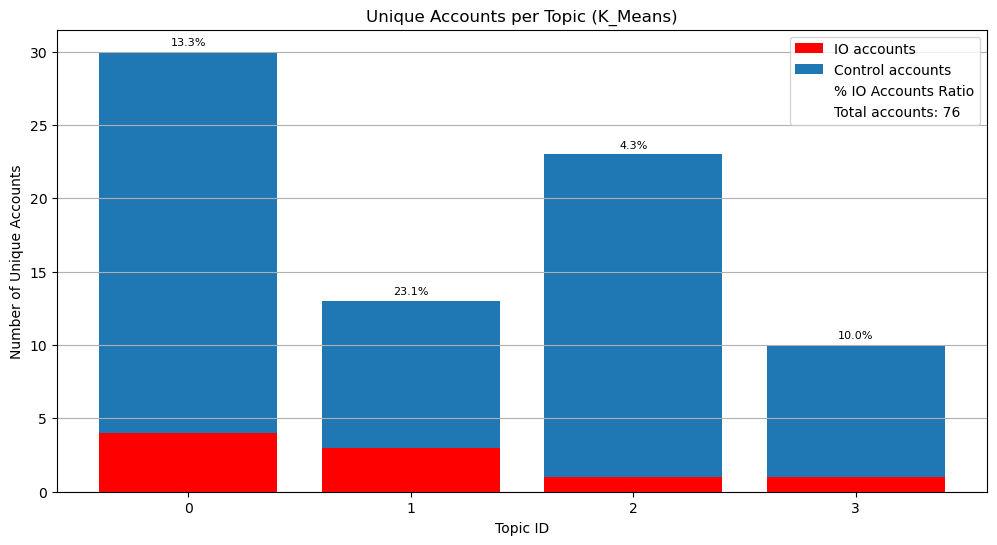

In [40]:
topic_col_name = "K_Means_topic"

topic_account_stats = make_topic_account_stats(df, topic_col_name)
display(topic_account_stats)
plot_topic_account_stats(topic_account_stats, topic_col_name, "K_Means", output_folder_path)

# Named Entity Recognition (NER)

In [41]:
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

# Load model ONCE
tokenizer = AutoTokenizer.from_pretrained("TweebankNLP/bertweet-tb2_wnut17-ner")
ner_model = AutoModelForTokenClassification.from_pretrained("TweebankNLP/bertweet-tb2_wnut17-ner")

ner_pipeline = pipeline(
    "token-classification",
    model=ner_model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)


def extract_ner_entities(posts_lst: list):
    """
    Runs NER in batches on a list of text posts.

    Args:
          posts_lst (list): List of strings (cleaned posts).
    Returns
    -------
    all_entities (list[list[str]]): For each post: a list of extracted entity words.
    """

    ner_outputs = ner_pipeline(posts_lst)
    all_entities = []
    for post_output in ner_outputs:
        words = [ent["word"] for ent in post_output]
        all_entities.append(words)

    return all_entities

Device set to use cuda:0


In [42]:
# Apply ONCE, no pandas apply, in order to utilize batches.
df["ner_entities"] = extract_ner_entities(df["clean_post_text"].to_list())

In [43]:
df.loc[df["ner_entities"].astype(bool), ["clean_post_text", "ner_entities"]].head()

,clean_post_text,ner_entities
12447,mention_9d72355c890e1bb8530156865c0d4172bc3a2926cd alguien sabe q pasa en la arc la altura del antiguo peaje de hoyo de la puerta? ahí mucha cola...,[pu@@]
39489,"hashtag_messi , feliz porque su país se siente “orgulloso” de él url_c45b5d07c7547ecc3bec497b91663a6170362bc8ff",[messi]
49498,para hashtag_barcelona hashtag_bsc ganarle hashtag_liga hashtag_ldu es un sueño... es mision imposible! catedra en la cancha en las gradas grande liga mb &lt;3,"[barcelona, ed@@]"
36958,alguien podría enumerar los logros de la defensoría del pueblo mention_ed92ae882a10c6c57aad6af994794bab65e5f47188 ; sin contar la defensa de hashtag_cacho ?,[pueblo]
43106,más de 200 muertos en incendio en cárcel de hashtag_honduras . url_1fc26ec3624b619ad0c1ad0e2faa26d02797241f7a hashtag_mundo,[dur@@]


# Entities Cleanup

In [44]:
def clean_entity_columns(df, entity_cols_lst):
    """Normalize entity columns to match TfidfVectorizer behavior.

    Converts each entity to a stripped, lowercase string for all columns
    listed in ``entity_cols_lst``. 
    The function modifies ``df``.

    Args:
        df: Input DataFrame.
        entity_cols_lst: Columns containing lists of entities.

    Returns:
        None.
    """
    for col in entity_cols_lst:
        df[col] = df[col].apply(lambda lst: [str(e).strip().lower().replace(" ", "_") for e in lst])

In [45]:
entity_cols_lst = ["hashtags", "account_mentions", "urls", "ner_entities"]
clean_entity_columns(df, entity_cols_lst)

# Entities Statistics

In [46]:
import pandas as pd

def compute_entity_topic_matrix(df, entity_col, topic_col="topic_id", is_control_col="is_control", output_folder_path=None):
    """
    Create a df where values = number of times the entity appears in each topic.

    Args:
        df (pd.DataFrame):
            DataFrame containing posts, entity lists, topic labels and is_control.
        entity_col (str):
            Column containing a list of entities per post.
        topic_col (str):
            Column containing topic labels.
        is_control_col (str):
            Boolean column: True = legitimate, False = IO.

    Returns:
        entity_topic_counts (pd.DataFrame):
            Columns:
                [entity, total_count, io_percent, topic_ids = 1, 2, 3...]
    """

    # 1) Explode entity lists → one row per (entity, topic, is_control)
    df_exp = (
        df[[entity_col, topic_col, is_control_col]]
        .explode(entity_col)
        .dropna(subset=[entity_col])
        .copy()
    )

    # 2) Aggregate counts per entity (overall)
    entity_stats = (
        df_exp.groupby(entity_col)
              .agg(
                  total_count=(entity_col, "count"),
                  io_count=(is_control_col, lambda x: (~x).sum()),  # False = IO
              )
              .reset_index()
    )
    entity_stats["io_percent"] = 100 * entity_stats["io_count"] / entity_stats["total_count"]
    entity_stats = entity_stats[[entity_col, "total_count", "io_percent"]]

    # 3) Count occurrences per (entity, topic)
    entity_topic_counts = (
        df_exp.groupby([entity_col, topic_col])
              .size()
              .reset_index(name="count")
    )

    # 4) Pivot to wide format (entity rows × topic columns)
    entity_topic_counts = (
        entity_topic_counts
        .pivot_table(
            index=entity_col,
            columns=topic_col,
            values="count",
            fill_value=0
        )
        .sort_index(axis=1)   # ensure topic columns sorted: 0,1,2,...
        .reset_index()
    )

    # 5) Merge total_count + IO stats
    entity_topic_counts = entity_stats.merge(entity_topic_counts, on=entity_col, how="left")

    # 6) Sort by total_count (descending)
    entity_topic_counts = entity_topic_counts.sort_values("total_count", ascending=False)

    # 7) Save if path provided
    if output_folder_path:
        output_path = Path(output_folder_path) / f"entity_topic_matrix.gzip.parquet"
        df.to_parquet(output_path, index=False, compression="gzip")
        print(f"Saved to {output_path}")

    return entity_topic_counts

In [47]:
import matplotlib.pyplot as plt

def plot_entity_topic_distribution(entity, entity_topic_counts, entity_col, clustering_model="", output_folder_path=None):
    """
    Plot how many times a given entity appears in each topic.
    """

    # Extract row for chosen entity
    row = entity_topic_counts.loc[entity_topic_counts[entity_col] == entity].iloc[0]

    # Keep only topic columns (s)
    topic_cols = [c for c in entity_topic_counts.columns if isinstance(c, int)]
    counts = row[topic_cols]       # Series like [topic_id → count]

    # --- Plot ---
    plt.figure(figsize=(12, 5))
    plt.bar(topic_cols, counts)

    plt.title(f"Topic Distribution for Entity: '{entity}'")
    plt.xlabel("Topic ID")
    plt.ylabel("Count of occurrences")
    plt.xticks(topic_cols)
    plt.grid(axis="y")
    plt.ylim(0, counts.max()* 1.15 ) # y-axis height: 15% padding above the tallest bar
    # Add metadata note (top-right)
    plt.text(
        0.98, 0.92,
        f"clustering model: {clustering_model}\nEntities col: {entity_col}",
        ha="right",
        va="top",
        transform=plt.gca().transAxes
    )

    # plot
    plt.tight_layout()

    # Save if path provided
    if output_folder_path:
        plot_path = output_folder_path / f"{entity}_topic_distribution.png"
        plt.savefig(plot_path, dpi=300)
        print(f"Saved figure to: {plot_path}")

    plt.show()

    plt.close()

,ner_entities,total_count,io_percent,-1
22,peru,2,0.0,2.0
9,ecuador,2,0.0,2.0
0,afric@@,1,0.0,1.0
1,arco,1,0.0,1.0
3,barcelona,1,0.0,1.0


Saved figure to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_1/2025_12_14/peru_topic_distribution.png


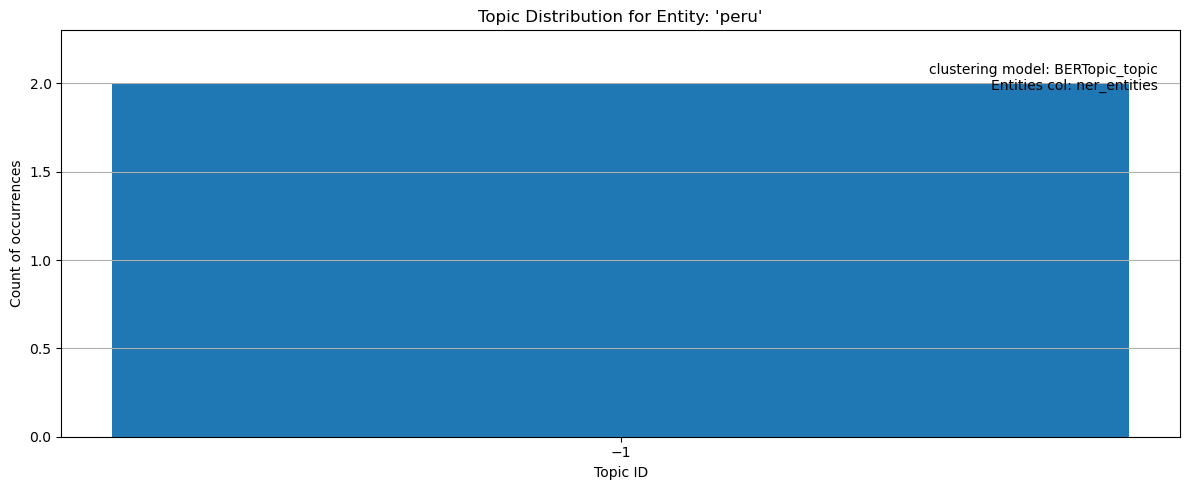

In [48]:
entity_col_name = "ner_entities"
topic_col = "BERTopic_topic"

entity_topic_matrix = compute_entity_topic_matrix(df, entity_col_name, topic_col)
display(entity_topic_matrix.head())

entity = entity_topic_matrix[entity_col_name].iloc[0]   # first entity
plot_entity_topic_distribution(entity=entity, entity_topic_counts=entity_topic_matrix, entity_col=entity_col_name, clustering_model = topic_col, output_folder_path=output_folder_path)

# Save to parquet

In [49]:
# print dataset statistics
for col in df.columns:
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col:<30} | {type(sample_val).__name__}")

postid                         | str
post_text                      | str
application_name               | str
post_language                  | str
in_reply_to_postid             | str
in_reply_to_accountid          | str
post_time                      | Timestamp
accountid                      | str
account_profile_description    | str
follower_count                 | int64
following_count                | int64
account_creation_date          | date
is_repost                      | bool
reposted_accountid             | str
reposted_postid                | str
hashtags                       | list
urls                           | list
account_mentions               | list
is_control                     | bool
clean_post_text                | str
clean_text_no_enteties         | str
translated_post                | str
BERTopic_topic                 | int64
BERTopic_prob                  | float64
K_Means_topic                  | int32
ner_entities                   | list


In [50]:
df_output_path = output_folder_path / f"Topic_Ner_{file_name}"

df.to_parquet(df_output_path, index=False, compression="gzip")
print("df is saved to:", df_output_path)

df is saved to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_1/2025_12_14/Topic_Ner_Ecuador_part_1.gzip.parquet
